# Training a REINFORCE racing agent

This notebook presents the project-owned REINFORCE implementation on the continuous-control car-racing problem. It deliberately uses `agents/reinforce.py` and the readable loop in `training/engines/reinforce.py`; the experiment-oriented shared engine is not involved.

The equations and boundary conventions summarized here come from [`docs/LEARNING.md`](../docs/LEARNING.md). The environment state, reward, and circuit representation are specified in [`docs/MDP.md`](../docs/MDP.md) and [`docs/TRACK.md`](../docs/TRACK.md).

## What REINFORCE does in this project

The actor receives a normalized Frenet observation and parametrizes a Gaussian distribution over an unbounded action $U_t$. The environment action is $A_t=\tanh(U_t)$, which keeps throttle and steering inside $[-1,1]$. The agent owns the corrected log-probability calculation for this bounded policy.

REINFORCE has no critic and therefore no bootstrap value. It waits for complete trajectories. For each trajectory it computes return-to-go backwards, with both termination and time-limit truncation acting as episode boundaries:

$$G_t = R_{t+1} + \gamma G_{t+1}.$$

Returns are standardized once across every transition in the collected episode batch. The loss is a sum over each trajectory and then an average over trajectories. The default project configuration updates after eight complete episodes, collected concurrently as one trajectory in each of eight persistent CPU workers.

## Configuration

All choices used by this demonstration are visible below. They are educational settings, not reported-experiment settings. `NUM_ENVS` is tied to the configured number of complete trajectories per update. The experimental `actor_weight_decay=1e-4` applies only to the actor MLP weight matrices; biases and the learned log standard deviations remain unregularized, following `docs/LEARNING.md`. Set `TRAIN_ON_MULTIPLE_CIRCUITS` to choose between the single seed and the tuple of circuit seeds. When several circuits are enabled, each worker selects one at every episode boundary using its own random stream identity, separate from policy sampling and environment resets.

In [1]:
import sys
import time
import warnings
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning,
    module="pygame.pkgdata",
)

from agents import ReinforceAgent
from configs import (
    MEDIUM_ACTOR_CONFIG,
    EnvironmentConfig,
    ExecutionConfig,
    ObservationNormalizationConfig,
    ReinforceConfig,
)
from envs.racing import RacingEnv
from envs.tracks import TrackWithGeometry
from recording import RunCategory
from training.engines.reinforce import ReinforceTrainingEngine
from training.evaluation import evaluate_deterministic
from training.normalization import RunningObservationNormalizer
from utils.random import (
    RunSeedStreams,
    SeedNamespace,
    SeedStream,
    configure_torch_determinism,
)

# Reproducibility and execution
ROOT_SEED = 0
DEVICE = "cpu"  # "cpu" or "cuda"
TRAINING_EPISODES = 1600  # Smoke setting; increase for a learning run.

# Circuit choice
TRAIN_ON_MULTIPLE_CIRCUITS = False
SINGLE_CIRCUIT_SEED = 0
MULTIPLE_CIRCUIT_SEEDS = (0, 1, 2)

# Actor and REINFORCE choices
ACTOR_CONFIG = replace(MEDIUM_ACTOR_CONFIG, learning_rate=3e-4)
REINFORCE_CONFIG = ReinforceConfig(
    discount=0.9995,
    completed_episodes_per_update=16,
    actor_weight_decay=1e-4,
)
NUM_ENVS = REINFORCE_CONFIG.completed_episodes_per_update
ENVIRONMENT_CONFIG = EnvironmentConfig()
NORMALIZATION_CONFIG = ObservationNormalizationConfig()

# Greedy evaluation and plotting
EVALUATION_CIRCUIT_INDEX = 0
EVALUATION_INTERVAL_EPISODES = 64
EVALUATION_EPISODES = 16
MOVING_AVERAGE_WINDOW = 20

# Live rendered rollouts
RENDER_CIRCUIT_INDEX = 0
RENDER_RESET_SEED = 123
VIEWER_MODE = "inline"  # "inline" or "window"
LIVE_RENDER_MAX_STEPS = 300
LIVE_FRAME_DELAY = 0.01

torch.cuda.is_available()

True

## Build circuits, random streams, agent, and engine

The circuit seeds are explicit. A single root identity derives separate generators for actor initialization plus worker-indexed generators for policy sampling, environment resets, and training-circuit selection, following the seed contract in `docs/LEARNING.md`. The normalizer updates only when an observation is a current training input.

In [2]:
execution_config = ExecutionConfig(device=DEVICE, environment_workers=NUM_ENVS)
configure_torch_determinism(execution_config)
streams = RunSeedStreams(SeedNamespace.MULTI_CIRCUIT_DEVELOPMENT, ROOT_SEED)

circuit_seeds = (
    MULTIPLE_CIRCUIT_SEEDS if TRAIN_ON_MULTIPLE_CIRCUITS else (SINGLE_CIRCUIT_SEED,)
)
tracks = tuple(
    TrackWithGeometry.generate(
        seed,
        track_config=ENVIRONMENT_CONFIG.track,
        vehicle_config=ENVIRONMENT_CONFIG.vehicle,
    )
    for seed in circuit_seeds
)

probe_environment = RacingEnv(tracks[0], config=ENVIRONMENT_CONFIG)
observation_dimensions = probe_environment.observation_space.shape[0]
probe_environment.close()

agent = ReinforceAgent(
    observation_dimensions=observation_dimensions,
    actor_config=ACTOR_CONFIG,
    config=REINFORCE_CONFIG,
    initialization_generator=streams.get_torch_generator(
        SeedStream.ACTOR_INITIALIZATION, device=DEVICE
    ),
    sampling_generator=tuple(
        streams.get_torch_generator(
            SeedStream.POLICY_ACTION_SAMPLING,
            device=DEVICE,
            substream_identity=index,
        )
        for index in range(NUM_ENVS)
    ),
    device=DEVICE,
)
normalizer = RunningObservationNormalizer(observation_dimensions, NORMALIZATION_CONFIG)
print("X")
engine = ReinforceTrainingEngine(
    agent=agent,
    tracks=tracks,
    environment_config=ENVIRONMENT_CONFIG,
    normalizer=normalizer,
    environment_reset_generator=tuple(
        streams.get_numpy_generator(
            SeedStream.ENVIRONMENT_RESETS, substream_identity=index
        )
        for index in range(NUM_ENVS)
    ),
    track_selection_generator=tuple(
        streams.get_numpy_generator(
            SeedStream.TRAINING_TRACK_SELECTION, substream_identity=index
        )
        for index in range(NUM_ENVS)
    ),
    execution_config=execution_config,
)
print("A")
evaluation_generator = streams.get_numpy_generator(SeedStream.EVALUATION)
print("B")

print(f"Circuits used for training: {circuit_seeds}")
print(f"Observation dimensions: {observation_dimensions}")
print(f"Actor parameters: {agent.actor_config.hidden_sizes}")

X
A
B
Circuits used for training: (0,)
Observation dimensions: 4
Actor parameters: (64, 64)


## The policy before training

Evaluation uses the deterministic bounded mean action and frozen normalization statistics. The viewer updates after every environment step, so it shows the initial actor actively interacting without consuming the policy-sampling stream used for training. Use `VIEWER_MODE = "window"` if your notebook frontend does not animate inline output.

In [3]:
def watch_rendered_rollout(title, track):
    if VIEWER_MODE not in {"inline", "window"}:
        raise ValueError("VIEWER_MODE must be 'inline' or 'window'.")

    render_mode = "rgb_array" if VIEWER_MODE == "inline" else "human"
    environment = RacingEnv(track, config=ENVIRONMENT_CONFIG, render_mode=render_mode)
    observation, info = environment.reset(seed=RENDER_RESET_SEED)
    total_return = 0.0
    figure = None

    if VIEWER_MODE == "inline":
        figure, axis = plt.subplots(figsize=(7, 7))
        image = axis.imshow(environment.render())
        axis.axis("off")
        display_handle = display(figure, display_id=True)
    else:
        environment.render()

    try:
        for step in range(1, LIVE_RENDER_MAX_STEPS + 1):
            normalized_observation = normalizer.normalize(observation)
            action = agent.deterministic_action(normalized_observation)
            observation, reward, terminated, truncated, info = environment.step(action)
            total_return += float(reward)

            if VIEWER_MODE == "inline":
                image.set_data(environment.render())
                axis.set_title(f"{title} | step {step} | return {total_return:.2f}")
                display_handle.update(figure)
            else:
                environment.render()
            time.sleep(LIVE_FRAME_DELAY)
            if terminated or truncated:
                break
    finally:
        environment.close()
        if figure is not None:
            plt.close(figure)

    return {
        "interactions": step,
        "return": total_return,
        "collision": bool(info["collision"]),
        "lap_completed": bool(info["lap_completed"]),
        "progress": float(info["episode_progress"]) / track.track.track_length,
    }

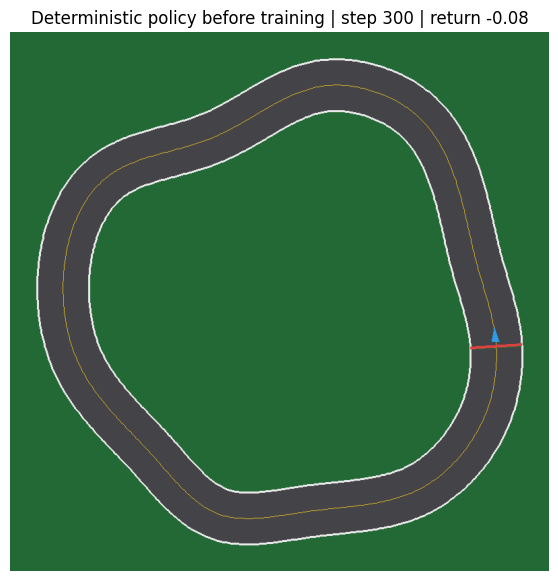

{'interactions': 300,
 'return': -0.08286110175550264,
 'collision': False,
 'lap_completed': False,
 'progress': 0.007138898244497263}

In [4]:
initial_rollout = watch_rendered_rollout(
    "Deterministic policy before training", tracks[RENDER_CIRCUIT_INDEX]
)
initial_rollout

## Scheduled deterministic evaluation

The deterministic evaluator uses the bounded actor mean, frozen observation normalization, a fresh environment, and the independent evaluation seed stream from `docs/LEARNING.md`. The episode callback runs after a possible eight-trajectory REINFORCE update, so an evaluation at a batch boundary observes the updated actor. An evaluation before training supplies the baseline point.

In [4]:
evaluation_rows = []
evaluation_state = {"interactions": 0}
evaluation_track = tracks[EVALUATION_CIRCUIT_INDEX]


def run_greedy_evaluation(completed_training_episodes, training_interactions):
    for _ in range(EVALUATION_EPISODES):
        result = evaluate_deterministic(
            lambda: RacingEnv(evaluation_track, config=ENVIRONMENT_CONFIG),
            agent,
            normalizer,
            run_category=RunCategory.REDUCED_VALIDATION,
            evaluation_index=len(evaluation_rows),
            training_interactions=training_interactions,
            evaluation_interactions_before=evaluation_state["interactions"],
            reset_seed=int(evaluation_generator.integers(0, 2**32, dtype=np.uint32)),
            root_identity=ROOT_SEED,
            circuit_identity=str(evaluation_track.track.generation.seed),
        )
        episode = result.record.episode
        evaluation_state["interactions"] = result.record.evaluation_interactions
        evaluation_rows.append(
            {
                "evaluation_index": result.record.evaluation_index,
                "completed_training_episodes": completed_training_episodes,
                "training_interactions": training_interactions,
                "return": episode.undiscounted_return,
                "outcome": episode.outcome.value,
                "maximum_progress": episode.maximum_progress,
                "mean_speed": episode.speed.mean,
            }
        )


def evaluate_on_schedule(episode_record, current_history):
    completed_episodes = episode_record.episode_index + 1
    if completed_episodes % EVALUATION_INTERVAL_EPISODES == 0:
        run_greedy_evaluation(completed_episodes, current_history.training_interactions)


run_greedy_evaluation(0, 0)
evaluation_rows[-1]

{'evaluation_index': 15,
 'completed_training_episodes': 0,
 'training_interactions': 0,
 'return': -0.22255647133180323,
 'outcome': 'time_limit',
 'maximum_progress': 0.07744352866819665,
 'mean_speed': 0.6226439306481043}

## Train

The educational engine performs the complete loop directly across eight persistent environment processes: update and normalize the current observation batch, sample one bounded action from each worker's policy stream, step concurrently, and store each detached transition in its own trajectory. A worker that finishes is parked until the other trajectories in the batch finish. Then `ReinforceAgent.update` computes return-to-go separately, standardizes returns across the batch, forms the documented loss, and applies one optimizer step.

In [5]:
try:
    history = engine.train(
        TRAINING_EPISODES,
        on_episode_end=evaluate_on_schedule,
    )
finally:
    engine.close()

print(f"Episodes collected: {len(history.episodes)}")
print(f"Training interactions: {history.training_interactions}")
print(f"Optimizer updates: {len(history.updates)}")
print(f"Unused complete trajectories: {TRAINING_EPISODES % agent.collection_size}")
print(f"Greedy evaluations: {len(evaluation_rows)}")

Training episodes:   0%|          | 0/1600 [00:00<?, ?episode/s]

Episodes collected: 1600
Training interactions: 1325384
Optimizer updates: 100
Unused complete trajectories: 0
Greedy evaluations: 416


## Inspect the collected records

Episode records show the circuit, outcome, return, interaction count, progress, mean speed, and mean throttle magnitude. Return, speed, and throttle magnitude pair their raw per-episode values with trailing 20-episode means. The REINFORCE loss similarly pairs each raw update value with a trailing 20-update mean. Greedy evaluation records remain separate from training. Actor weight norm is recorded before each optimizer update because weights stay unchanged between updates. The final panel converts the two learned log standard deviations into the Gaussian exploration scales $\boldsymbol\sigma=\exp(\boldsymbol\ell)$ specified in `docs/LEARNING.md`.

In [6]:
episode_rows = []
for record in history.episodes:
    row = asdict(record)
    row["outcome"] = record.outcome.value
    episode_rows.append(row)

update_rows = [asdict(record) for record in history.updates]

print("First five episode records:")
for row in episode_rows[:5]:
    print(row)

print("\nLast five episode records:")
for row in episode_rows[-5:]:
    print(row)

print("\nFirst three update records:")
for row in update_rows[:3]:
    print(row)

print("\nGreedy evaluation records:")
for row in evaluation_rows:
    print(row)

First five episode records:
{'episode_index': 0, 'circuit_identity': '0', 'interactions': 574, 'undiscounted_return': -20.067019455843493, 'outcome': 'crashed', 'final_progress': 0.10513759871332043, 'maximum_progress': 0.10513759871332043, 'mean_speed': 1.4832280270385358, 'mean_throttle_magnitude': 0.4157380185747935}
{'episode_index': 1, 'circuit_identity': '0', 'interactions': 325, 'undiscounted_return': -19.982389838493773, 'outcome': 'crashed', 'final_progress': 0.11509452302518662, 'maximum_progress': 0.11509452302518662, 'mean_speed': 2.8744862616348725, 'mean_throttle_magnitude': 0.42775341262324496}
{'episode_index': 2, 'circuit_identity': '0', 'interactions': 348, 'undiscounted_return': -19.997418064243284, 'outcome': 'crashed', 'final_progress': 0.10682320270910975, 'maximum_progress': 0.10682320270910975, 'mean_speed': 2.489351727710716, 'mean_throttle_magnitude': 0.4246547777398393}
{'episode_index': 3, 'circuit_identity': '0', 'interactions': 523, 'undiscounted_return': 

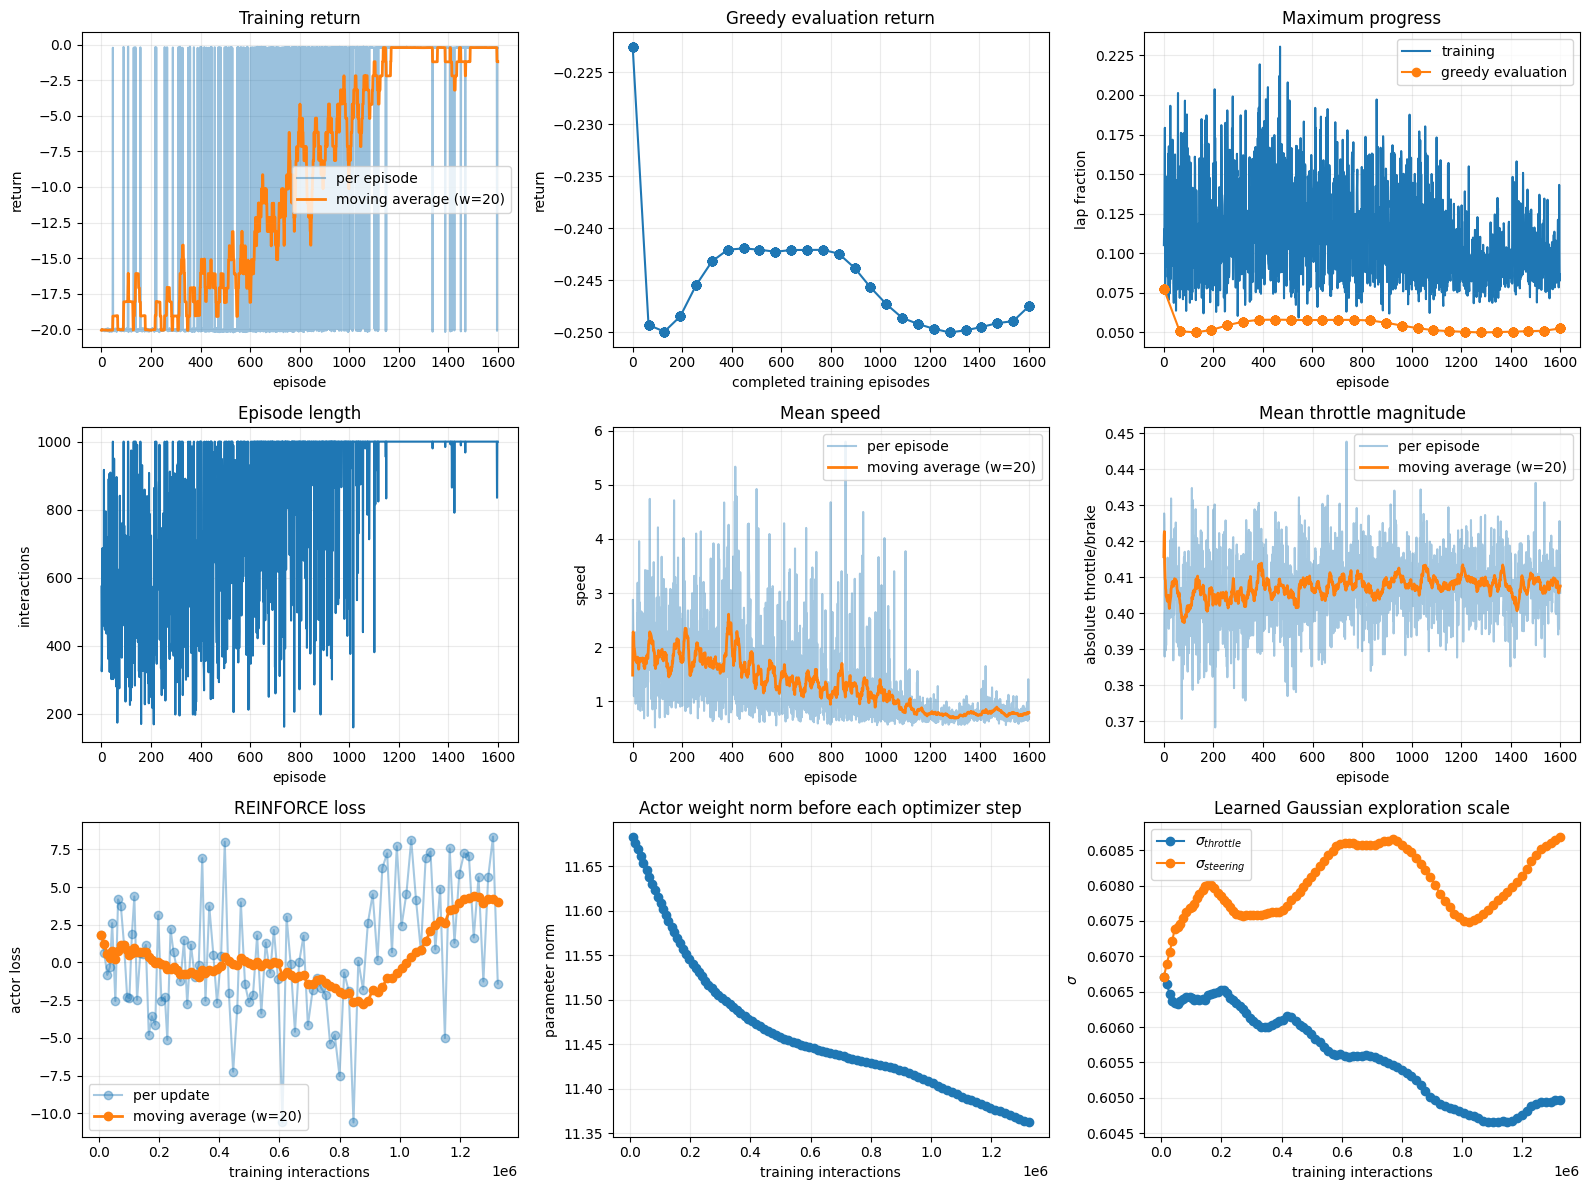

In [7]:
def trailing_average(values, window):
    return np.asarray(
        [
            np.mean(values[max(0, index - window + 1) : index + 1])
            for index in range(len(values))
        ]
    )


episode_indices = np.asarray([row["episode_index"] for row in episode_rows])
returns = np.asarray([row["undiscounted_return"] for row in episode_rows])
moving_returns = trailing_average(returns, MOVING_AVERAGE_WINDOW)
progress = np.asarray([row["maximum_progress"] for row in episode_rows])
lengths = np.asarray([row["interactions"] for row in episode_rows])
mean_speeds = np.asarray([row["mean_speed"] for row in episode_rows])
mean_throttle_magnitudes = np.asarray(
    [row["mean_throttle_magnitude"] for row in episode_rows]
)
moving_mean_speeds = trailing_average(mean_speeds, MOVING_AVERAGE_WINDOW)
moving_mean_throttle_magnitudes = trailing_average(
    mean_throttle_magnitudes, MOVING_AVERAGE_WINDOW
)
update_interactions = np.asarray([row["training_interactions"] for row in update_rows])
actor_losses = np.asarray([row["diagnostics"]["actor_loss"] for row in update_rows])
moving_actor_losses = trailing_average(actor_losses, MOVING_AVERAGE_WINDOW)
actor_weight_norms = np.asarray(
    [row["diagnostics"]["actor_weight_norm"] for row in update_rows]
)
log_standard_deviations = np.asarray(
    [
        [
            row["diagnostics"]["log_standard_deviation_0"],
            row["diagnostics"]["log_standard_deviation_1"],
        ]
        for row in update_rows
    ]
).reshape(-1, 2)
sigmas = np.exp(log_standard_deviations)
evaluation_episodes = np.asarray(
    [row["completed_training_episodes"] for row in evaluation_rows]
)

figure, axes = plt.subplots(3, 3, figsize=(16, 12))
axes[0, 0].plot(episode_indices, returns, alpha=0.45, label="per episode")
axes[0, 0].plot(
    episode_indices, moving_returns, linewidth=2, label="moving average (w=20)"
)
axes[0, 0].set(title="Training return", xlabel="episode", ylabel="return")
axes[0, 0].legend()
axes[0, 1].plot(
    evaluation_episodes, [row["return"] for row in evaluation_rows], marker="o"
)
axes[0, 1].set(
    title="Greedy evaluation return",
    xlabel="completed training episodes",
    ylabel="return",
)
axes[0, 2].plot(episode_indices, progress, label="training")
axes[0, 2].plot(
    evaluation_episodes,
    [row["maximum_progress"] for row in evaluation_rows],
    marker="o",
    label="greedy evaluation",
)
axes[0, 2].set(title="Maximum progress", xlabel="episode", ylabel="lap fraction")
axes[0, 2].legend()
axes[1, 0].plot(episode_indices, lengths)
axes[1, 0].set(title="Episode length", xlabel="episode", ylabel="interactions")
axes[1, 1].plot(episode_indices, mean_speeds, alpha=0.4, label="per episode")
axes[1, 1].plot(
    episode_indices, moving_mean_speeds, linewidth=2, label="moving average (w=20)"
)
axes[1, 1].set(title="Mean speed", xlabel="episode", ylabel="speed")
axes[1, 1].legend()
axes[1, 2].plot(
    episode_indices, mean_throttle_magnitudes, alpha=0.4, label="per episode"
)
axes[1, 2].plot(
    episode_indices,
    moving_mean_throttle_magnitudes,
    linewidth=2,
    label="moving average (w=20)",
)
axes[1, 2].set(
    title="Mean throttle magnitude",
    xlabel="episode",
    ylabel="absolute throttle/brake",
)
axes[1, 2].legend()
axes[2, 0].plot(
    update_interactions, actor_losses, alpha=0.4, marker="o", label="per update"
)
axes[2, 0].plot(
    update_interactions,
    moving_actor_losses,
    linewidth=2,
    marker="o",
    label="moving average (w=20)",
)
axes[2, 0].set(
    title="REINFORCE loss", xlabel="training interactions", ylabel="actor loss"
)
axes[2, 0].legend()
axes[2, 1].plot(update_interactions, actor_weight_norms, marker="o")
axes[2, 1].set(
    title="Actor weight norm before each optimizer step",
    xlabel="training interactions",
    ylabel="parameter norm",
)
axes[2, 2].plot(
    update_interactions, sigmas[:, 0], marker="o", label=r"$\sigma_{throttle}$"
)
axes[2, 2].plot(
    update_interactions, sigmas[:, 1], marker="o", label=r"$\sigma_{steering}$"
)
axes[2, 2].set(
    title="Learned Gaussian exploration scale",
    xlabel="training interactions",
    ylabel=r"$\sigma$",
)
axes[2, 2].legend()
for axis in axes.flat:
    axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

## The policy after training

The final live rollout uses the same circuit, reset seed, deterministic action rule, and frozen normalizer as the initial view. This makes the visual comparison about the policy and the training-updated normalization state rather than exploration noise.

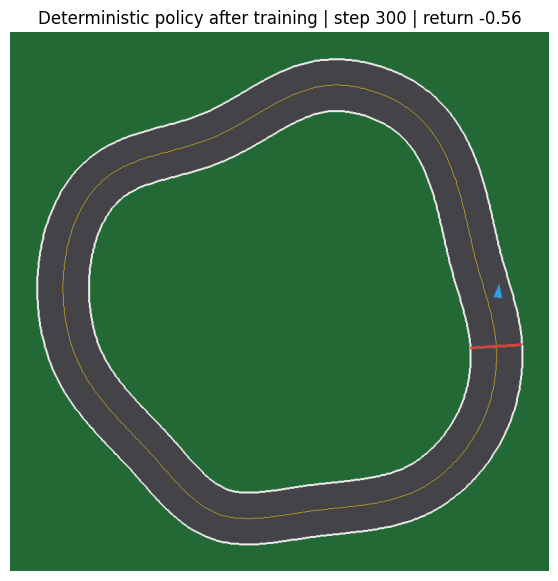

After training:  {'interactions': 300, 'return': -0.5623635599083989, 'collision': False, 'lap_completed': False, 'progress': 0.03763644009160137}


In [17]:
final_rollout = watch_rendered_rollout(
    "Deterministic policy after training", tracks[RENDER_CIRCUIT_INDEX]
)
# print("Before training:", initial_rollout)
print("After training: ", final_rollout)